In [1]:
import sys
import os

sys.path.append(os.path.abspath('../'))

from src.data_loader import load_silver_data
import matplotlib.pyplot as plt
import seaborn as sns

df = load_silver_data()

df['olist_orders_dataset'].head()

Buscando arquivos em: c:\Users\mgand\OneDrive\Desktop\bigdata\BigDataECommerce\data\silver
 -> olist_customers_dataset carregado. (99441 linhas)
 -> olist_geolocation_dataset carregado. (1000121 linhas)
 -> olist_orders_dataset carregado. (99441 linhas)
 -> olist_order_items_dataset carregado. (112545 linhas)
 -> olist_order_payments_dataset carregado. (103877 linhas)
 -> olist_order_reviews_dataset carregado. (98410 linhas)
 -> olist_products_dataset carregado. (32946 linhas)
 -> olist_sellers_dataset carregado. (3095 linhas)
 -> product_category_name_translation carregado. (72 linhas)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,is_delivered,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,True,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,True,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,True,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,True,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,True,False


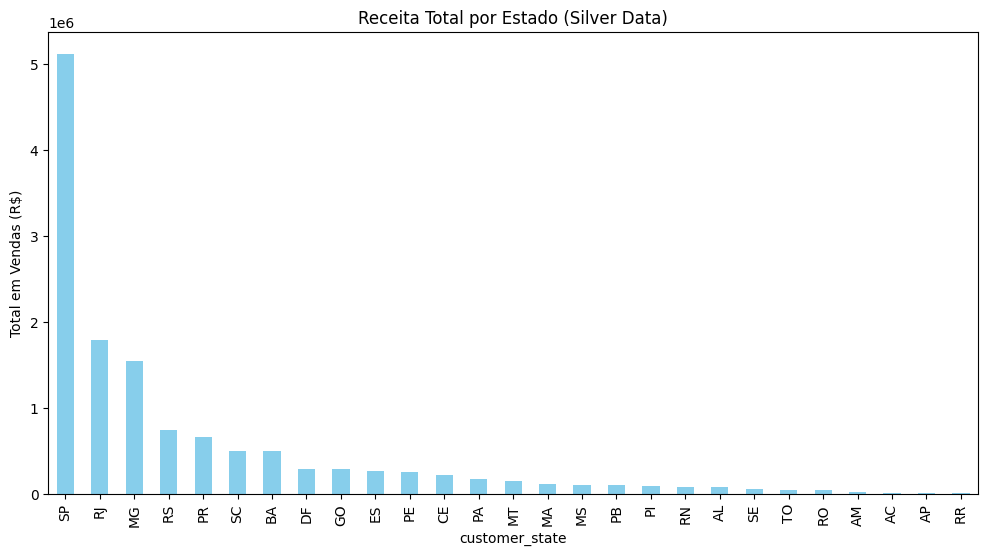

In [ ]:
df_vendas = df['olist_order_items_dataset'].merge(df['olist_orders_dataset'], on='order_id')
df_vendas = df_vendas.merge(df['olist_customers_dataset'], on='customer_id')

receita_estado = df_vendas.groupby('customer_state')['price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
receita_estado.plot(kind='bar', color='skyblue')
plt.title('Receita Total por Estado (Silver Data)')
plt.ylabel('Total em Vendas (R$)')
plt.show()